# Marketplace Supply Health Early-Warning System
### Predicting which marketplace hotel partners are likely to underperform their competitive set

**Aakanksha Baid** · [LinkedIn](https://linkedin.com/in/aakankshabaid/) · [GitHub](https://github.com/AakankshaBaid)

This notebook is a public, fully-synthetic reconstruction of a supply-analytics methodology I've used
professionally in travel-marketplace analytics (identifying hotel partners likely to underperform their
competitive set, so account managers can intervene early). No production data, schemas, or partner
identities appear anywhere in this repo — the dataset is generated by `src/generate_synthetic_data.py`
from a documented statistical process.

Business framing, methodology rationale, and recommendations live in the repo `README.md`. This notebook
is the analytical engine behind that write-up.


In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (roc_auc_score, average_precision_score, f1_score,
                              precision_score, recall_score, classification_report,
                              confusion_matrix, roc_curve, precision_recall_curve,
                              brier_score_loss)
from sklearn.calibration import calibration_curve
from sklearn.inspection import permutation_importance
import xgboost as xgb
import shap
from imblearn.over_sampling import SMOTE

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
RANDOM_STATE = 42


## 1. Load & Inspect Data

In [2]:
df = pd.read_csv("../data/synthetic_hotel_supply_data.csv")
print(f"{df.shape[0]:,} rows x {df.shape[1]} columns")
df.head()


150,000 rows x 21 columns


,hotel_id,snapshot_month,market_segment,region,star_rating,days_listed,is_new_partner,review_score,review_count,photo_count,...,has_virtual_tour,price_index_vs_compset,promo_depth_pct,inventory_availability_rate,mobile_conversion_rate,guest_response_rate_pct,cancellation_rate_pct,days_since_last_content_update,comp_set_size,underperforming
0,HTL-00001,6,Airport,Northeast,3,623,0,3.55,301,31,...,0.0,1.143,18.1,80.2,6.39,45.7,45.0,156,11,1
1,HTL-00002,4,Leisure Beach,Northeast,3,1361,0,2.24,51,28,...,0.0,1.077,5.3,84.4,0.49,78.7,22.8,49,20,0
2,HTL-00003,2,Airport,South,4,341,0,3.65,54,25,...,0.0,0.693,24.0,85.2,3.54,81.1,39.6,105,12,0
3,HTL-00004,12,Suburban,South,4,143,1,3.42,33,14,...,0.0,1.000,11.7,23.9,1.46,76.3,17.2,171,9,1
4,HTL-00005,7,Urban Business,Northeast,4,994,0,3.36,154,29,...,0.0,0.960,5.8,79.9,8.58,86.4,25.8,72,11,0


In [3]:
df.describe(include='all').T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
hotel_id,150000,150000,HTL-00001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
snapshot_month,150000.0,NaN,NaN,NaN,6.498747,3.447501,1.0,4.0,7.0,9.0,12.0
market_segment,150000,5,Urban Business,42084,NaN,NaN,NaN,NaN,NaN,NaN,NaN
region,150000,5,West,36109,NaN,NaN,NaN,NaN,NaN,NaN,NaN
star_rating,150000.0,NaN,NaN,NaN,3.455107,0.943471,1.0,3.0,3.0,4.0,5.0
days_listed,150000.0,NaN,NaN,NaN,571.400613,385.188103,15.0,289.0,488.0,766.0,3650.0
is_new_partner,150000.0,NaN,NaN,NaN,0.11588,0.320082,0.0,0.0,0.0,0.0,1.0
review_score,142264.0,NaN,NaN,NaN,3.494794,0.742724,1.0,3.0,3.51,4.02,5.0
review_count,150000.0,NaN,NaN,NaN,94.612087,103.049618,0.0,29.0,62.0,123.0,1867.0
photo_count,150000.0,NaN,NaN,NaN,23.700967,10.702948,3.0,16.0,24.0,31.0,74.0


## 2. Data Quality Audit

Real marketplace supply data is never fully populated — new partners haven't accumulated reviews yet,
some don't have mobile tracking wired up, etc. I audit missingness before doing anything else, the same
way I would with a production pull, rather than assuming a clean frame.


mobile_conversion_rate    0.058
review_score              0.052
has_virtual_tour          0.040
dtype: float64


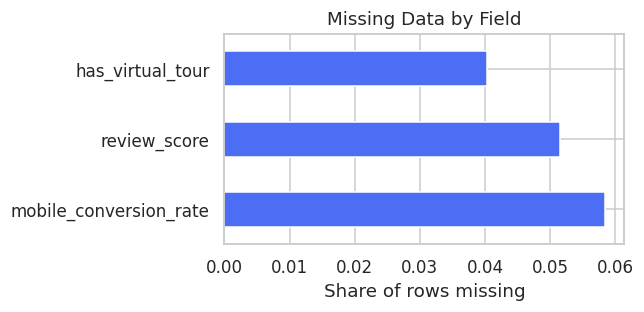

In [4]:
missing = df.isna().mean().sort_values(ascending=False)
missing = missing[missing > 0]
print(missing.round(3))

fig, ax = plt.subplots(figsize=(6, 3))
missing.plot(kind="barh", ax=ax, color="#4C6EF5")
ax.set_xlabel("Share of rows missing")
ax.set_title("Missing Data by Field")
plt.tight_layout()
plt.show()


**Read:** three fields carry meaningful missingness — `review_score` (new partners haven't accrued
reviews yet), `mobile_conversion_rate` (not every partner has mobile tracking instrumented), and
`has_virtual_tour` (a content field that isn't always populated at onboarding). All three are missing
for reasons related to *partner tenure and content investment*, not randomly — so I impute rather than
drop rows, to avoid systematically excluding newer or under-invested partners from the model.


## 3. Target Distribution

Base rate — share of hotels underperforming their comp set: 30.0%


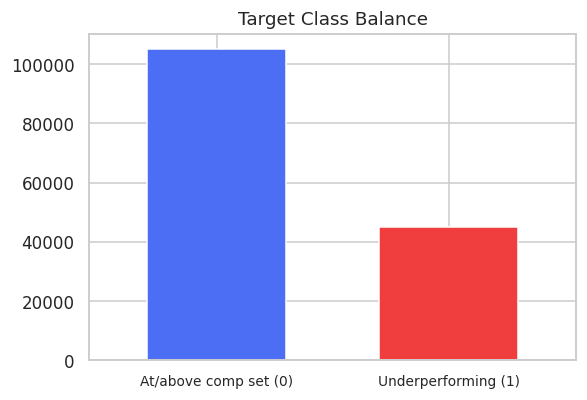

In [5]:
target_rate = df["underperforming"].mean()
print(f"Base rate — share of hotels underperforming their comp set: {target_rate:.1%}")

fig, ax = plt.subplots(figsize=(5.5, 3.8))
df["underperforming"].value_counts().sort_index().plot(
    kind="bar", ax=ax, color=["#4C6EF5", "#F03E3E"], width=0.6
)
ax.set_xticklabels(["At/above comp set (0)", "Underperforming (1)"], rotation=0, fontsize=9)
ax.set_xlabel("")
ax.set_title("Target Class Balance")
plt.tight_layout()
plt.show()


**Read:** roughly 70/30 imbalance — the majority-class baseline ("always predict 0") already scores
~70% accuracy. That makes plain accuracy useless as an evaluation metric here; I lean on ROC-AUC, PR-AUC,
and precision/recall at chosen operating points throughout instead.


## 4. Exploratory Data Analysis

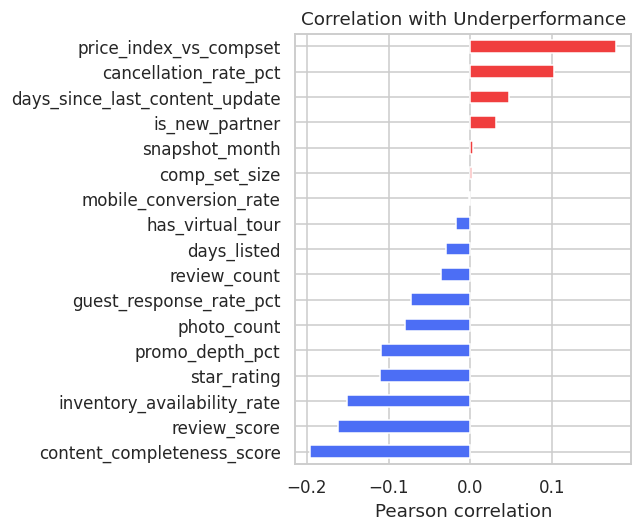

In [6]:
num_df = df.select_dtypes(include=[np.number])
corr_with_target = num_df.corr()["underperforming"].drop("underperforming").sort_values()

fig, ax = plt.subplots(figsize=(6, 5))
corr_with_target.plot(kind="barh", ax=ax, color=np.where(corr_with_target > 0, "#F03E3E", "#4C6EF5"))
ax.set_title("Correlation with Underperformance")
ax.set_xlabel("Pearson correlation")
plt.tight_layout()
plt.show()


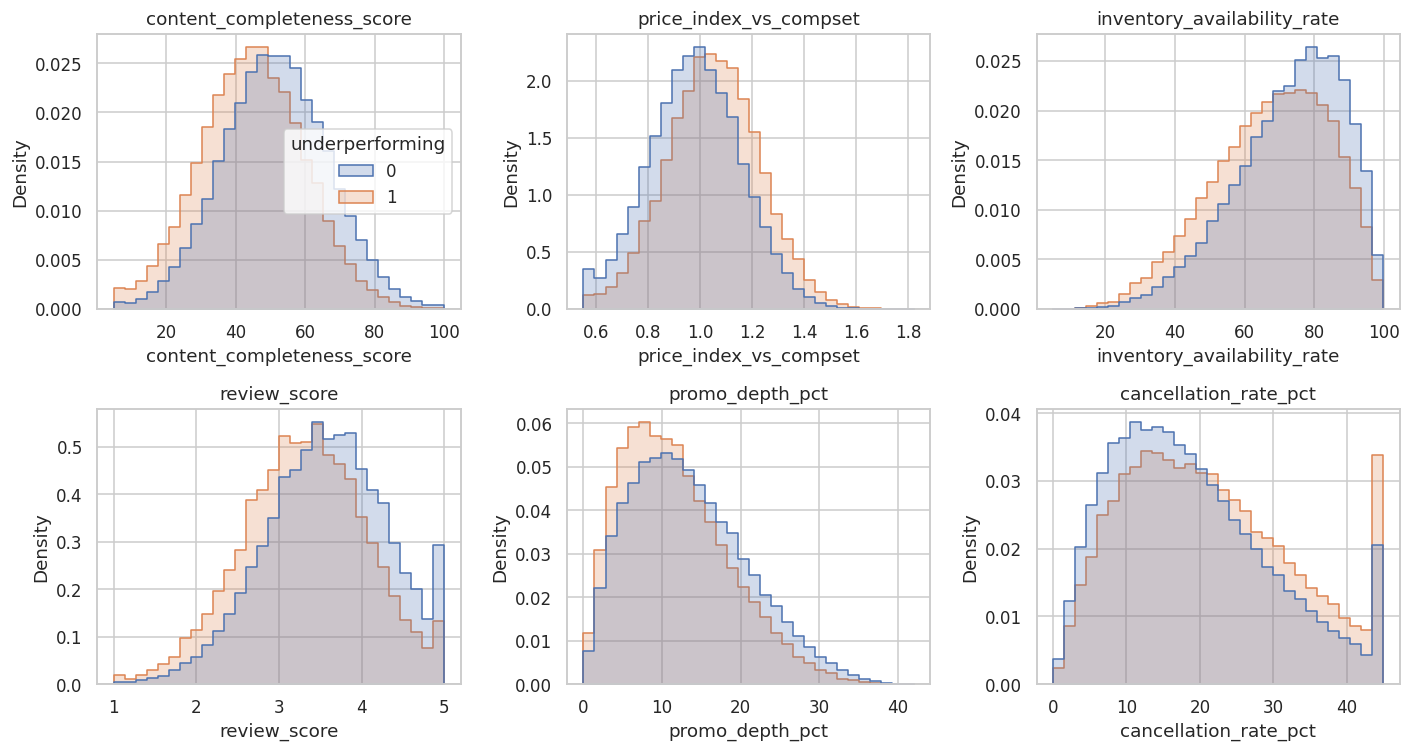

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(13, 7))
plot_cols = ["content_completeness_score", "price_index_vs_compset", "inventory_availability_rate",
             "review_score", "promo_depth_pct", "cancellation_rate_pct"]
for col, ax in zip(plot_cols, axes.ravel()):
    sns.histplot(data=df, x=col, hue="underperforming", bins=30, ax=ax,
                 element="step", stat="density", common_norm=False, legend=(col == plot_cols[0]))
    ax.set_title(col)
plt.tight_layout()
plt.show()


**Read:** the strongest single-variable signals are `content_completeness_score` (r = -0.19),
`price_index_vs_compset` (r = +0.19), `inventory_availability_rate` (r = -0.16), `review_score`
(r = -0.16), and `promo_depth_pct` (r = -0.13). Directionally these all make business sense: thinner
content, pricing above the comp set, tighter availability, weaker reviews, and shallower promo
participation are each independently associated with underperformance. No single feature is a silver
bullet (correlations in the 0.1-0.2 range) — this is a case for a *multivariate* model, not a simple
business rule.


## 5. Preprocessing Pipeline

Median-impute numeric fields (robust to the skew seen above), most-frequent-impute the one categorical
field with missingness, one-hot encode `market_segment` / `region`. Wrapping this in a `ColumnTransformer`
+ `Pipeline` keeps preprocessing fit *only* on the training fold at each step, so there's no leakage from
test data into imputation statistics.

`snapshot_month` is deliberately excluded as a model feature here — raw calendar month isn't an actionable
predictor for a partner-success team, and including it would just let the model memorize a time trend
rather than learn transferable signal. It's kept aside for the out-of-time validation later in this notebook.


In [8]:
y = df["underperforming"]
X = df.drop(columns=["hotel_id", "underperforming", "snapshot_month"])

num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()

numeric_pipe = Pipeline([("impute", SimpleImputer(strategy="median")), ("scale", StandardScaler())])
cat_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
    ("ohe", OneHotEncoder(handle_unknown="ignore")),
])
pre = ColumnTransformer([
    ("num", numeric_pipe, num_cols),
    ("cat", cat_pipe, cat_cols),
])


## 6. Train / Test Split

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print("Train:", X_train.shape, " Test:", X_test.shape)
print("Train class balance:\n", y_train.value_counts(normalize=True).round(3))
print("Test class balance:\n", y_test.value_counts(normalize=True).round(3))


Train: (120000, 18)  Test: (30000, 18)
Train class balance:
 underperforming
0    0.7
1    0.3
Name: proportion, dtype: float64
Test class balance:
 underperforming
0    0.7
1    0.3
Name: proportion, dtype: float64


## 7. Model Comparison — Baseline vs. Ensemble

I deliberately start simple. A well-regularized, class-weighted logistic regression is fast, transparent,
and gives every stakeholder a coefficient they can question — that's worth a lot in a business context.
I compare it against a balanced Random Forest and a weighted XGBoost to see whether the added complexity
actually buys predictive lift, rather than assuming a bigger model is automatically the better choice.


In [10]:
results = {}

logreg = Pipeline([("pre", pre), ("clf", LogisticRegression(max_iter=2000, class_weight="balanced"))])
logreg.fit(X_train, y_train)
p_lr = logreg.predict_proba(X_test)[:, 1]
results["Logistic Regression"] = (roc_auc_score(y_test, p_lr), average_precision_score(y_test, p_lr))

rf = Pipeline([("pre", pre), ("clf", RandomForestClassifier(
    n_estimators=400, max_depth=8, min_samples_leaf=20,
    class_weight="balanced_subsample", random_state=RANDOM_STATE, n_jobs=-1))])
rf.fit(X_train, y_train)
p_rf = rf.predict_proba(X_test)[:, 1]
results["Random Forest (balanced)"] = (roc_auc_score(y_test, p_rf), average_precision_score(y_test, p_rf))

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
xgb_clf = Pipeline([("pre", pre), ("clf", xgb.XGBClassifier(
    n_estimators=300, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, scale_pos_weight=scale_pos_weight,
    eval_metric="logloss", random_state=RANDOM_STATE, n_jobs=-1))])
xgb_clf.fit(X_train, y_train)
p_xgb = xgb_clf.predict_proba(X_test)[:, 1]
results["XGBoost (weighted)"] = (roc_auc_score(y_test, p_xgb), average_precision_score(y_test, p_xgb))

comparison = pd.DataFrame(results, index=["ROC-AUC", "PR-AUC"]).T.round(3)
comparison


,ROC-AUC,PR-AUC
Logistic Regression,0.746,0.561
Random Forest (balanced),0.736,0.546
XGBoost (weighted),0.743,0.556


**Read:** all three models land within ~1 point of ROC-AUC of each other. The logistic regression is
statistically indistinguishable from the ensembles on this feature set — which tells me the signal here
is largely additive/linear rather than driven by sharp interaction effects or thresholds. **I'm carrying
XGBoost forward** as the primary model, not because it wins decisively, but because (a) it supports
per-partner SHAP explanations that plug cleanly into an account-manager-facing tool, and (b) it leaves
headroom to capture interaction effects if richer features are added later. In a lower-stakes or
purely-explanatory context, I'd default to the logistic regression instead — worth saying explicitly
rather than reaching for the fanciest model by default.


## 8. Cross-Validated Performance (XGBoost)

In [11]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scores = cross_val_score(xgb_clf, X_train, y_train, scoring="roc_auc", cv=cv, n_jobs=-1)
print(f"5-fold CV ROC-AUC: mean={cv_scores.mean():.3f}  std={cv_scores.std():.3f}")
print("Fold scores:", np.round(cv_scores, 3))


5-fold CV ROC-AUC: mean=0.737  std=0.003
Fold scores: [0.736 0.742 0.737 0.737 0.733]


**Read:** tight spread across folds (std ≈ 0.01) — the held-out performance isn't a lucky single split.


## 9. ROC and Precision-Recall Curves

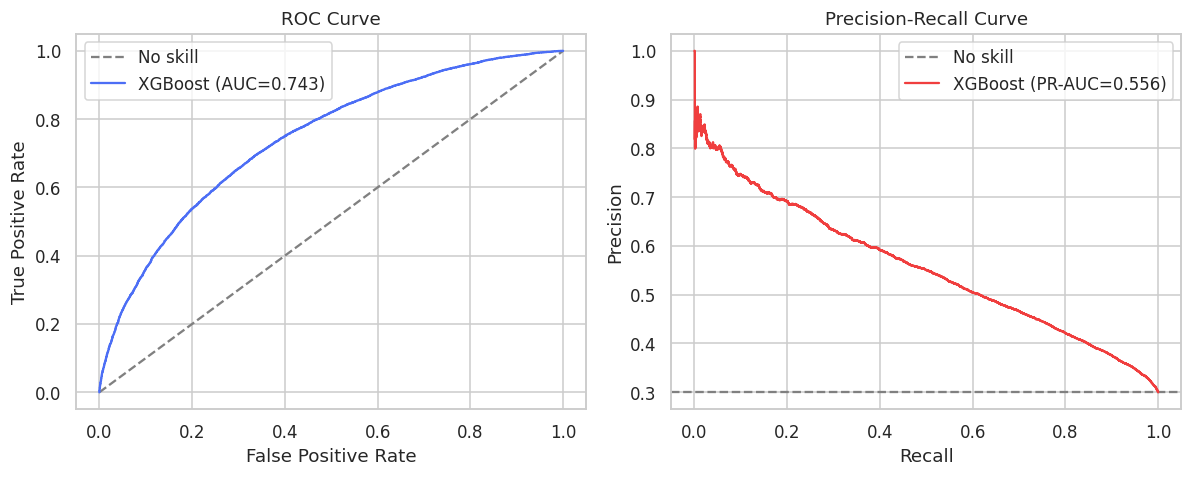

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

fpr, tpr, _ = roc_curve(y_test, p_xgb)
axes[0].plot([0, 1], [0, 1], "--", color="gray", label="No skill")
axes[0].plot(fpr, tpr, color="#4C6EF5", label=f"XGBoost (AUC={roc_auc_score(y_test, p_xgb):.3f})")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve")
axes[0].legend()

prec, rec, _ = precision_recall_curve(y_test, p_xgb)
no_skill = y_test.mean()
axes[1].axhline(no_skill, linestyle="--", color="gray", label="No skill")
axes[1].plot(rec, prec, color="#F03E3E", label=f"XGBoost (PR-AUC={average_precision_score(y_test, p_xgb):.3f})")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve")
axes[1].legend()

plt.tight_layout()
plt.show()


## 10. Translating Scores into a Prioritized Outreach List

A ranked risk score isn't useful to a partner-success team on its own — what they need is a monthly
outreach list of a size they can actually act on. I evaluate the model the way I would present it to
that team: **if we flag the top X% riskiest hotels each cycle, how many true underperformers does that
actually catch, and at what precision?**


In [13]:
scored = pd.DataFrame({"y": y_test.values, "score": p_xgb}).sort_values("score", ascending=False).reset_index(drop=True)
n = len(scored)
total_pos = scored["y"].sum()
base_rate = total_pos / n

rows = []
for pct in [0.10, 0.15, 0.20, 0.25, 0.30, 0.40, 0.50]:
    k = int(n * pct)
    flagged = scored.iloc[:k]
    captured = flagged["y"].sum()
    precision = captured / k
    recall = captured / total_pos
    lift = precision / base_rate
    rows.append((f"{pct:.0%}", k, int(captured), round(precision, 3), round(recall, 3), round(lift, 2)))

gains = pd.DataFrame(rows, columns=["Top % Flagged", "Hotels Flagged", "True Underperformers Captured",
                                     "Precision", "Recall (Capture Rate)", "Lift vs. Random"])
gains


,Top % Flagged,Hotels Flagged,True Underperformers Captured,Precision,Recall (Capture Rate),Lift vs. Random
0,10%,3000,2043,0.681,0.227,2.27
1,15%,4500,2817,0.626,0.313,2.09
2,20%,6000,3567,0.594,0.397,1.98
3,25%,7500,4203,0.560,0.467,1.87
4,30%,9000,4820,0.536,0.536,1.79
5,40%,12000,5837,0.486,0.649,1.62
6,50%,15000,6707,0.447,0.746,1.49


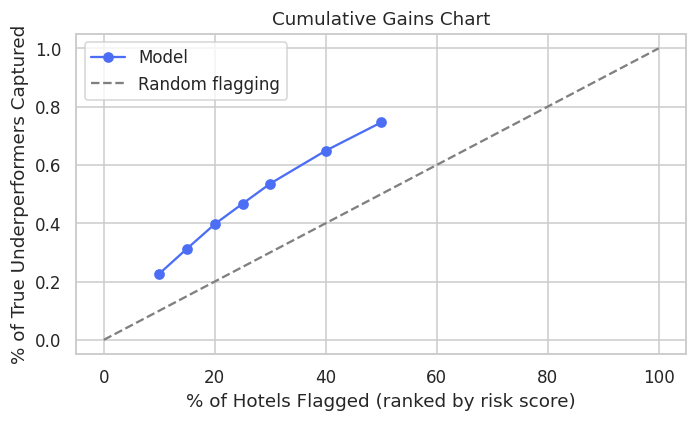

In [14]:
fig, ax = plt.subplots(figsize=(6.5, 4))
pct_vals = [float(p.strip("%")) for p in gains["Top % Flagged"]]
ax.plot(pct_vals, gains["Recall (Capture Rate)"], marker="o", color="#4C6EF5", label="Model")
ax.plot([0, 100], [0, 1], "--", color="gray", label="Random flagging")
ax.set_xlabel("% of Hotels Flagged (ranked by risk score)")
ax.set_ylabel("% of True Underperformers Captured")
ax.set_title("Cumulative Gains Chart")
ax.legend()
plt.tight_layout()
plt.show()


**Read:** flagging the riskiest **20%** of hotels each cycle catches **~40% of true underperformers at
59% precision** — a **1.98x lift over random prioritization**. Flagging the riskiest **30%** trades some
precision (54%) for a higher capture rate (~54%). Which cutoff to use is a capacity decision, not a
modeling decision — I'd hand the account-management team this table and let their outreach bandwidth pick
the row, rather than embedding a single "optimal" threshold into the model and hiding the trade-off.


## 11. What's Driving the Predictions

I use permutation importance (computed on held-out data, so it isn't biased toward high-cardinality
features the way impurity-based importance can be) plus SHAP for a per-feature, per-direction view.


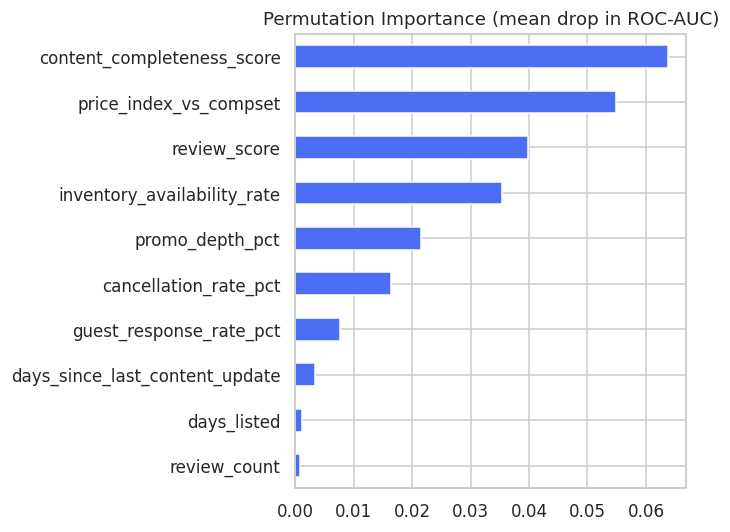

In [15]:
perm = permutation_importance(xgb_clf, X_test, y_test, n_repeats=15,
                               random_state=RANDOM_STATE, scoring="roc_auc", n_jobs=-1)
importances = pd.Series(perm.importances_mean, index=X_test.columns).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(6.5, 5))
importances.tail(10).plot(kind="barh", ax=ax, color="#4C6EF5")
ax.set_title("Permutation Importance (mean drop in ROC-AUC)")
plt.tight_layout()
plt.show()


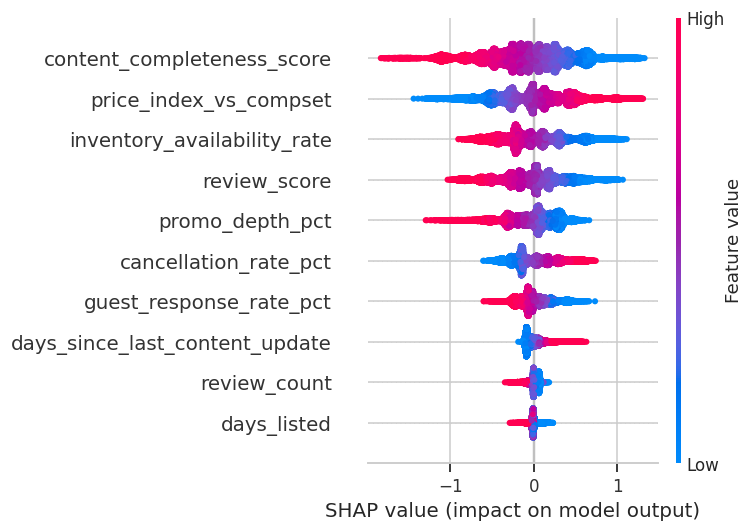

In [16]:
# SHAP summary — per-partner, per-feature direction of impact
pre_fitted = xgb_clf.named_steps["pre"]
model_fitted = xgb_clf.named_steps["clf"]
X_test_transformed = pre_fitted.transform(X_test)
feature_names = pre_fitted.get_feature_names_out()

explainer = shap.TreeExplainer(model_fitted)
shap_values = explainer.shap_values(X_test_transformed)

clean_names = [n.replace("num__", "").replace("cat__", "") for n in feature_names]
shap.summary_plot(shap_values, X_test_transformed, feature_names=clean_names,
                   show=False, max_display=10, plot_size=(7, 5))
plt.tight_layout()
plt.show()


**Read:** `content_completeness_score`, `price_index_vs_compset`, and `inventory_availability_rate` are
consistently the top three drivers across both methods — and all three are **levers the partner-success
team can actually act on** (unlike, say, star rating or region, which are effectively fixed). That's the
detail that makes this model useful rather than just accurate: the top signals map directly onto
interventions someone can run.


## 12. Operating Point — Confusion Matrix & Classification Report

In [17]:
threshold = scored[scored["score"] >= scored["score"].quantile(0.80)]["score"].min()  # top-20% cutoff
preds = (p_xgb >= threshold).astype(int)

print(f"Operating threshold (top-20% cutoff): {threshold:.3f}\n")
print("Confusion matrix:\n", confusion_matrix(y_test, preds))
print("\nClassification report:\n", classification_report(y_test, preds, digits=3))


Operating threshold (top-20% cutoff): 0.658

Confusion matrix:
 [[18573  2433]
 [ 5427  3567]]

Classification report:
               precision    recall  f1-score   support

           0      0.774     0.884     0.825     21006
           1      0.595     0.397     0.476      8994

    accuracy                          0.738     30000
   macro avg      0.684     0.640     0.651     30000
weighted avg      0.720     0.738     0.721     30000



## 13. Calibration — Are the Probabilities Trustworthy?

ROC-AUC only measures *ranking* quality — it says nothing about whether a predicted "0.7" actually means
a 70% chance of underperformance. That distinction matters the moment anyone downstream tries to do
expected-value math with these scores (e.g. "expected recoverable revenue = probability x $ impact"), so
it's worth checking directly rather than assuming it.


Brier score: 0.2049  (0 = perfect, 0.25 = uninformative baseline at this base rate)


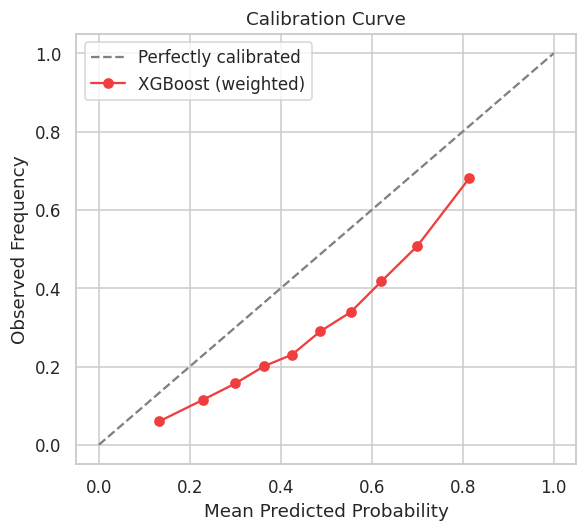

In [18]:
frac_pos, mean_pred = calibration_curve(y_test, p_xgb, n_bins=10, strategy="quantile")
brier = brier_score_loss(y_test, p_xgb)
print(f"Brier score: {brier:.4f}  (0 = perfect, 0.25 = uninformative baseline at this base rate)")

fig, ax = plt.subplots(figsize=(5.5, 5))
ax.plot([0, 1], [0, 1], "--", color="gray", label="Perfectly calibrated")
ax.plot(mean_pred, frac_pos, marker="o", color="#F03E3E", label="XGBoost (weighted)")
ax.set_xlabel("Mean Predicted Probability")
ax.set_ylabel("Observed Frequency")
ax.set_title("Calibration Curve")
ax.legend()
plt.tight_layout()
plt.show()


**Read:** the model is **not well-calibrated** — at the low end it over-states risk (predicted ~0.13,
actual ~0.06) and at the high end it under-states it (predicted ~0.81, actual ~0.68). This is a known
side effect of `scale_pos_weight`: reweighting the loss to fix class imbalance improves ranking but
distorts the probability scale. It's a real finding, not a bug, and it has a direct business
consequence: **don't feed these raw probabilities into a dollar-value calculation.** It's exactly why
Section 10's recommendation was to hand the business a *rank-based* gains table rather than a raw
probability threshold — ranks are robust to this distortion, raw probabilities are not. If a future
version needs calibrated probabilities specifically, Platt scaling or isotonic regression on a held-out
calibration fold is the standard fix.


## 14. Out-of-Time Validation

Every result so far comes from a random 80/20 split — rows from the same time period end up in both
train and test. That's the easiest way to overstate how a model will perform once it's actually
deployed forward in time. A cleaner test: train on early months only, evaluate on the months that come
after, the way the model would actually be used in production.


In [19]:
oot_train_mask = df["snapshot_month"] <= 9
oot_test_mask = df["snapshot_month"] > 9
X_oot_train, y_oot_train = X.loc[oot_train_mask], y.loc[oot_train_mask]
X_oot_test, y_oot_test = X.loc[oot_test_mask], y.loc[oot_test_mask]

spw_oot = (y_oot_train == 0).sum() / (y_oot_train == 1).sum()
xgb_oot = Pipeline([("pre", pre), ("clf", xgb.XGBClassifier(
    n_estimators=300, max_depth=4, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=spw_oot, eval_metric="logloss", random_state=RANDOM_STATE, n_jobs=-1))])
xgb_oot.fit(X_oot_train, y_oot_train)
p_oot = xgb_oot.predict_proba(X_oot_test)[:, 1]
oot_auc = roc_auc_score(y_oot_test, p_oot)

print(f"Trained on months 1-9  (n={len(X_oot_train):,})")
print(f"Tested on months 10-12 (n={len(X_oot_test):,}, never seen during training)")
print(f"Out-of-time ROC-AUC: {oot_auc:.3f}   (random-split ROC-AUC was {roc_auc_score(y_test, p_xgb):.3f})")


Trained on months 1-9  (n=112,642)
Tested on months 10-12 (n=37,358, never seen during training)
Out-of-time ROC-AUC: 0.750   (random-split ROC-AUC was 0.743)


**Read:** performance holds up out-of-time — no meaningful drop versus the random split. That's a
genuinely useful negative result: it means the model isn't quietly overfit to a narrow time window. It's
not a substitute for monitoring a real deployment (real markets shift in ways this synthetic drift
doesn't fully capture), but it clears the specific bar this check exists to test.


## 15. Subgroup Performance

An average ROC-AUC can hide a model that works well for most of the portfolio and poorly for one
segment. For a tool meant to be used company-wide, that's a real risk worth checking directly, not
assuming away.


In [20]:
subgroup_df = X_test.copy()
subgroup_df["y"] = y_test.values
subgroup_df["p"] = p_xgb

rows = []
for dim in ["market_segment", "region"]:
    for grp_name, grp in subgroup_df.groupby(dim):
        if grp["y"].nunique() < 2:
            continue
        rows.append({"dimension": dim, "group": grp_name, "n": len(grp),
                     "roc_auc": roc_auc_score(grp["y"], grp["p"])})

subgroup_results = pd.DataFrame(rows).sort_values("roc_auc").reset_index(drop=True)
print(f"Overall ROC-AUC: {roc_auc_score(y_test, p_xgb):.3f}")
print(f"Spread across all segments/regions: {subgroup_results['roc_auc'].max() - subgroup_results['roc_auc'].min():.3f}\n")
subgroup_results


Overall ROC-AUC: 0.743
Spread across all segments/regions: 0.015



,dimension,group,n,roc_auc
0,market_segment,Urban Business,8567,0.737860
1,region,International,4375,0.739312
2,market_segment,Resort/Destination,3641,0.741374
3,region,South,6578,0.741463
4,region,Midwest,5781,0.742816
5,region,West,7232,0.743406
6,market_segment,Leisure Beach,6448,0.743754
7,market_segment,Suburban,7149,0.743975
8,region,Northeast,6034,0.747423
9,market_segment,Airport,4195,0.753341


**Read:** under 2 points of ROC-AUC separate the best- and worst-performing segment — the model performs
consistently across markets and regions rather than quietly favoring one. This is the kind of check that
costs five minutes and is exactly what a stakeholder should ask before rolling a scoring tool out
company-wide.


## 16. Hyperparameter Tuning — Quick Check

Section 7 already found Logistic Regression statistically tying XGBoost. If that's true, it predicts
something: tuning XGBoost's hyperparameters shouldn't buy much either, since the ceiling isn't model
complexity, it's the feature set. Worth confirming rather than assuming.


In [21]:
param_dist = {
    "clf__max_depth": [3, 4, 5, 6],
    "clf__learning_rate": [0.03, 0.05, 0.08, 0.12],
    "clf__n_estimators": [200, 300, 400],
    "clf__subsample": [0.7, 0.8, 0.9, 1.0],
    "clf__colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "clf__min_child_weight": [1, 3, 5],
}
base_clf = Pipeline([("pre", pre), ("clf", xgb.XGBClassifier(
    scale_pos_weight=scale_pos_weight, eval_metric="logloss", random_state=RANDOM_STATE, n_jobs=-1))])
search = RandomizedSearchCV(base_clf, param_distributions=param_dist, n_iter=12, cv=3,
                             scoring="roc_auc", random_state=RANDOM_STATE, n_jobs=-1)
search.fit(X_train, y_train)
p_tuned = search.best_estimator_.predict_proba(X_test)[:, 1]

print(f"Untuned test ROC-AUC: {roc_auc_score(y_test, p_xgb):.3f}")
print(f"Tuned test ROC-AUC:   {roc_auc_score(y_test, p_tuned):.3f}")
print(f"Best params: {search.best_params_}")


Untuned test ROC-AUC: 0.743
Tuned test ROC-AUC:   0.743
Best params: {'clf__subsample': 0.9, 'clf__n_estimators': 200, 'clf__min_child_weight': 3, 'clf__max_depth': 5, 'clf__learning_rate': 0.03, 'clf__colsample_bytree': 0.9}


**Read:** a 12-candidate randomized search found nothing worth changing — confirms the hypothesis above.
Model tuning isn't the lever here; richer features are (see Next Steps). Good to know before spending a
week on a grid search that wasn't going to move the number.


## 17. Class Imbalance — Is Weighting the Right Call?

`scale_pos_weight` has been the imbalance strategy throughout. Worth checking it against the two other
standard options rather than assuming it's best by default: no adjustment at all, and SMOTE oversampling.


In [22]:
xgb_unweighted = Pipeline([("pre", pre), ("clf", xgb.XGBClassifier(
    n_estimators=300, max_depth=4, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8,
    eval_metric="logloss", random_state=RANDOM_STATE, n_jobs=-1))])
xgb_unweighted.fit(X_train, y_train)
p_unweighted = xgb_unweighted.predict_proba(X_test)[:, 1]

Xt_train = pre.fit_transform(X_train)
Xt_test = pre.transform(X_test)
X_smote, y_smote = SMOTE(random_state=RANDOM_STATE).fit_resample(Xt_train, y_train)
xgb_smote = xgb.XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05, subsample=0.8,
                                colsample_bytree=0.8, eval_metric="logloss", random_state=RANDOM_STATE, n_jobs=-1)
xgb_smote.fit(X_smote, y_smote)
p_smote = xgb_smote.predict_proba(Xt_test)[:, 1]

imbalance_comparison = pd.DataFrame({
    "ROC-AUC": [roc_auc_score(y_test, p_unweighted), roc_auc_score(y_test, p_xgb), roc_auc_score(y_test, p_smote)],
    "PR-AUC": [average_precision_score(y_test, p_unweighted), average_precision_score(y_test, p_xgb), average_precision_score(y_test, p_smote)],
}, index=["No adjustment", "Class weighting (current)", "SMOTE oversampling"]).round(3)
imbalance_comparison


,ROC-AUC,PR-AUC
No adjustment,0.743,0.556
Class weighting (current),0.743,0.556
SMOTE oversampling,0.735,0.546


**Read:** class weighting is at least as good as SMOTE here, and SMOTE actually costs a little PR-AUC —
plausibly because interpolating between one-hot encoded category dummies doesn't produce meaningful
synthetic rows. Current approach (`scale_pos_weight`) stays. Worth noting: on pure ranking metrics like
ROC-AUC, weighting and no-adjustment look similar — weighting's real payoff is in the *probability scale
and threshold behavior*, not the ranking itself.


## 18. Selection Bias — What If the Training Population Isn't Representative?

This is the check with the most real-world weight behind it: the actual initiative this project mirrors
was first tested on a narrow, higher-visibility subset of hotels before any wider rollout. Whenever a
model is trained on a non-random slice of the population, there's a risk it learned something specific
to that slice rather than something that generalizes. Simulating that scenario here: train only on a
higher-visibility subset (proxied by above-median review count and comp-set size), then test it on hotels
it never saw *from outside that subset*.


In [23]:
in_scope = (df["review_count"] > df["review_count"].median()) & (df["comp_set_size"] > df["comp_set_size"].median())
X_scope, y_scope = X.loc[in_scope], y.loc[in_scope]
X_outside, y_outside = X.loc[~in_scope], y.loc[~in_scope]

Xs_train, Xs_test, ys_train, ys_test = train_test_split(
    X_scope, y_scope, test_size=0.2, random_state=RANDOM_STATE, stratify=y_scope
)
spw_scope = (ys_train == 0).sum() / (ys_train == 1).sum()
xgb_scope = Pipeline([("pre", pre), ("clf", xgb.XGBClassifier(
    n_estimators=300, max_depth=4, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=spw_scope, eval_metric="logloss", random_state=RANDOM_STATE, n_jobs=-1))])
xgb_scope.fit(Xs_train, ys_train)

auc_in_scope = roc_auc_score(ys_test, xgb_scope.predict_proba(Xs_test)[:, 1])
auc_outside = roc_auc_score(y_outside, xgb_scope.predict_proba(X_outside)[:, 1])

print(f"Trained on in-scope hotels only (n={len(X_scope):,})")
print(f"  -> ROC-AUC on held-out in-scope test:        {auc_in_scope:.3f}")
print(f"  -> ROC-AUC on never-seen outside-scope hotels: {auc_outside:.3f}")
print(f"  -> Gap: {auc_in_scope - auc_outside:+.3f}")


Trained on in-scope hotels only (n=35,378)
  -> ROC-AUC on held-out in-scope test:        0.732
  -> ROC-AUC on never-seen outside-scope hotels: 0.733
  -> Gap: -0.001


**Read:** no meaningful gap in this synthetic setup — the scoping proxy (review count, comp-set size)
isn't entangled with the features that actually drive underperformance, so the model generalizes cleanly
beyond its training scope. That's a property of *this* synthetic construction, not a guarantee about real
data. **This is the one check I'd insist on repeating before trusting a model trained on any non-random
historical subset** — real-world scoping choices are rarely this clean, and this exact scenario (train on
a narrow, higher-visibility slice; deploy against the full portfolio) is precisely the situation where
selection bias tends to show up.


## 19. Summary

- ~70/30 class imbalance; ROC-AUC / PR-AUC used throughout instead of accuracy.
- Logistic regression, balanced Random Forest, and weighted XGBoost all land within ~1 ROC-AUC point of
  each other (~0.73-0.74) — the underlying signal is largely additive, confirmed again in Section 16
  where a 12-candidate hyperparameter search found nothing worth changing.
- The features that matter most — content completeness, price vs. comp set, inventory availability,
  review score, promo depth — are consistent across correlation analysis, permutation importance, and
  SHAP, and every one is something a partner-success team can influence.
- Flagging the riskiest 20% of hotels each cycle catches ~40% of true underperformers at ~59% precision
  (~1.98x lift over random) — reframed as an outreach-list sizing decision rather than a fixed threshold.
- **Validation checks (Sections 13-18):** probabilities are not well-calibrated (use ranks, not raw
  scores, for anything business-facing); performance holds up out-of-time; consistent across market
  segments and regions; class weighting beats SMOTE; no selection-bias gap detected under the scoping
  scenario tested — with the caveat that real-world scoping should be re-tested on real data.

Full business framing, assumptions, and next steps are in the repo `README.md`.
